
# Network Activity Anomaly Detection (AI Planet × C&A Club, IIT Guwahati)

> **Objective.** Build a model to classify network activity as **`normal (0)`** or **`neptune (1)`**.

**Competition notes (from challenge page & public notebooks):**
- Train rows ≈ **86,845**; Test rows ≈ **21,712** (indicative).
- Target column: **`attack`** (binary: `0 = normal`, `1 = neptune`).
- **Submission format:** a single column named **`attack`** (no ID column).
- **Primary metric used on the platform:** F1 (with precision/recall also tracked).

This notebook is structured to be clean, CV-ready, and reproducible.
It uses scikit‑learn Pipelines and robust handling of categorical features.


## 1. Setup & Imports

In [1]:

# Standard library
import os
import json
from pathlib import Path

# Data & utils
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# ML
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option('display.max_columns', 200)
print('Libraries imported.')

Libraries imported.


## 2. Load Data

In [7]:
# Expected file names (adjust if your files differ)
TRAIN_PATH = Path('train.csv')
TEST_PATH = Path('test.csv')
SAMPLE_SUB_PATH = Path('sample_submission.csv')

# Check if files exist
for p in [TRAIN_PATH, TEST_PATH, SAMPLE_SUB_PATH]:
    if not p.exists():
        print(f'⚠️ Expected file not found: {p.resolve()}')
        print('Please place train.csv, test.csv, and sample_submission.csv in the working directory.')

# Load data
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
sample_submission = pd.read_csv(SAMPLE_SUB_PATH)

print(train.shape, test.shape)
display(train.head(3))
display(test.head(3))
display(sample_submission.head(3))


(86845, 43) (21712, 42)


,duration,protocoltype,service,flag,srcbytes,dstbytes,land,wrongfragment,urgent,hot,numfailedlogins,loggedin,numcompromised,rootshell,suattempted,numroot,numfilecreations,numshells,numaccessfiles,numoutboundcmds,ishostlogin,isguestlogin,count,srvcount,serrorrate,srvserrorrate,rerrorrate,srvrerrorrate,samesrvrate,diffsrvrate,srvdiffhostrate,dsthostcount,dsthostsrvcount,dsthostsamesrvrate,dsthostdiffsrvrate,dsthostsamesrcportrate,dsthostsrvdiffhostrate,dsthostserrorrate,dsthostsrvserrorrate,dsthostrerrorrate,dsthostsrvrerrorrate,lastflag,attack
0,0,tcp,netbios_dgm,REJ,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,277,15,0.0,0.0,1.0,1.0,0.05,0.06,0.00,255,15,0.06,0.06,0.00,0.00,0.00,0.0,1.00,1.0,21,1
1,0,tcp,smtp,SF,1239,400,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,1,0.0,0.0,0.0,0.0,1.00,0.00,0.00,255,116,0.45,0.04,0.00,0.00,0.11,0.0,0.02,0.0,18,0
2,0,tcp,http,SF,222,945,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,21,25,0.0,0.0,0.0,0.0,1.00,0.00,0.08,57,255,1.00,0.00,0.02,0.03,0.00,0.0,0.00,0.0,21,0


,duration,protocoltype,service,flag,srcbytes,dstbytes,land,wrongfragment,urgent,hot,numfailedlogins,loggedin,numcompromised,rootshell,suattempted,numroot,numfilecreations,numshells,numaccessfiles,numoutboundcmds,ishostlogin,isguestlogin,count,srvcount,serrorrate,srvserrorrate,rerrorrate,srvrerrorrate,samesrvrate,diffsrvrate,srvdiffhostrate,dsthostcount,dsthostsrvcount,dsthostsamesrvrate,dsthostdiffsrvrate,dsthostsamesrcportrate,dsthostsrvdiffhostrate,dsthostserrorrate,dsthostsrvserrorrate,dsthostrerrorrate,dsthostsrvrerrorrate,lastflag
0,0,tcp,mtp,REJ,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,249,7,0.0,0.0,1.0,1.0,0.03,0.07,0.0,255,7,0.03,0.08,0.0,0.0,0.0,0.0,1.0,1.0,20
1,0,tcp,http,SF,199,1721,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,9,10,0.0,0.0,0.0,0.0,1.00,0.00,0.2,255,255,1.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,21
2,0,tcp,discard,S0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,16,6,1.0,1.0,0.0,0.0,0.38,0.38,0.0,255,14,0.05,0.09,0.0,0.0,1.0,1.0,0.0,0.0,18


,attack
0,0
1,0
2,0


## 3. Quick EDA

Train info:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
duration,86845.0,NaN,NaN,NaN,104.166872,1038.273538,0.0,0.0,0.0,0.0,40504.0
protocoltype,86845,3,tcp,75876,NaN,NaN,NaN,NaN,NaN,NaN,NaN
service,86845,65,http,31505,NaN,NaN,NaN,NaN,NaN,NaN,NaN
flag,86845,10,SF,50672,NaN,NaN,NaN,NaN,NaN,NaN,NaN
srcbytes,86845.0,NaN,NaN,NaN,8455.707191,358214.05588,0.0,0.0,46.0,272.0,89581520.0
dstbytes,86845.0,NaN,NaN,NaN,2732.09472,55430.411862,0.0,0.0,44.0,768.0,7028652.0
land,86845.0,NaN,NaN,NaN,0.000046,0.006787,0.0,0.0,0.0,0.0,1.0
wrongfragment,86845.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
urgent,86845.0,NaN,NaN,NaN,0.000035,0.007588,0.0,0.0,0.0,0.0,2.0
hot,86845.0,NaN,NaN,NaN,0.144971,1.837958,0.0,0.0,0.0,0.0,77.0



Target distribution:
attack
0    0.620036
1    0.379964
Name: proportion, dtype: float64

Detected categorical columns: ['protocoltype', 'service', 'flag']
Detected numeric columns: ['duration', 'srcbytes', 'dstbytes', 'land', 'wrongfragment', 'urgent', 'hot', 'numfailedlogins', 'loggedin', 'numcompromised', 'rootshell', 'suattempted', 'numroot', 'numfilecreations', 'numshells', 'numaccessfiles', 'numoutboundcmds', 'ishostlogin', 'isguestlogin', 'count', 'srvcount', 'serrorrate', 'srvserrorrate', 'rerrorrate', 'srvrerrorrate', 'samesrvrate', 'diffsrvrate', 'srvdiffhostrate', 'dsthostcount', 'dsthostsrvcount', 'dsthostsamesrvrate', 'dsthostdiffsrvrate', 'dsthostsamesrcportrate', 'dsthostsrvdiffhostrate', 'dsthostserrorrate', 'dsthostsrvserrorrate', 'dsthostrerrorrate', 'dsthostsrvrerrorrate', 'lastflag']


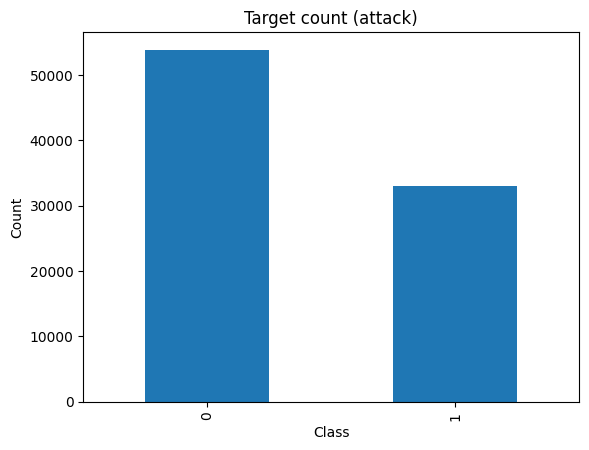

In [8]:

print('Train info:')
display(train.describe(include='all').transpose())

print('\nTarget distribution:')
if 'attack' not in train.columns:
    raise ValueError('`attack` column not found in train data. Please verify the target column name.')
print(train['attack'].value_counts(normalize=True).rename('proportion'))

# Identify categorical vs numeric automatically (robust to column name variants)
cat_cols = [c for c in train.columns if train[c].dtype == 'object' and c != 'attack']
num_cols = [c for c in train.columns if pd.api.types.is_numeric_dtype(train[c]) and c != 'attack']

# Known common KDD-like categorical columns may include protocol_type/service/flag (names sometimes vary)
# We keep automatic detection, but log what we found:
print('\nDetected categorical columns:', cat_cols)
print('Detected numeric columns:', num_cols)

# Simple bar plot for target
train['attack'].value_counts().plot(kind='bar')
plt.title('Target count (attack)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()


## 4. Preprocessing & Models

In [11]:

# Column transformer: One-hot encode categoricals; pass-through numerics
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
preprocess = ColumnTransformer(
    transformers=[
        ('cat', ohe, cat_cols),
        ('num', 'passthrough', num_cols),
    ]
)

# We'll try a few solid baselines with class weighting for imbalance:
models = {
    'LogReg': LogisticRegression(max_iter=1000, n_jobs=None, class_weight='balanced', solver='saga'),
    'RF'    : RandomForestClassifier(
        n_estimators=400, max_depth=None, min_samples_leaf=1,
        n_jobs=-1, random_state=RANDOM_STATE, class_weight='balanced_subsample'
    ),
    'HGB'   : HistGradientBoostingClassifier(random_state=RANDOM_STATE)  # strong tabular baseline
}

def make_pipeline(clf):
    return Pipeline(steps=[('preprocess', preprocess), ('clf', clf)])


## 5. Cross‑Validated Evaluation

In [12]:

X = train.drop(columns=['attack'])
y = train['attack']

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

results = {}
for name, clf in models.items():
    pipe = make_pipeline(clf)
    # cross_val_predict to get out-of-fold predictions for fair F1 estimate
    oof = cross_val_predict(pipe, X, y, cv=cv, method='predict', n_jobs=-1, verbose=0)
    f1 = f1_score(y, oof)
    results[name] = {'f1': f1}
    print(f'{name}: F1 = {f1:.5f}')

# Pick best by F1
best_name = max(results, key=lambda k: results[k]['f1'])
best_model = make_pipeline(models[best_name])
print('\nBest model by CV F1:', best_name, results[best_name])

# Fit best model on full training data
best_model.fit(X, y)
print('Best model fitted on full training data.')


LogReg: F1 = 0.99463
RF: F1 = 1.00000
HGB: F1 = 0.99986

Best model by CV F1: RF {'f1': 1.0}
Best model fitted on full training data.


### 5.1 Diagnostics on OOF (from best model type)

Classification Report (OOF):
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000     53847
           1     1.0000    1.0000    1.0000     32998

    accuracy                         1.0000     86845
   macro avg     1.0000    1.0000    1.0000     86845
weighted avg     1.0000    1.0000    1.0000     86845

Confusion Matrix (OOF):
 [[53847     0]
 [    0 32998]]


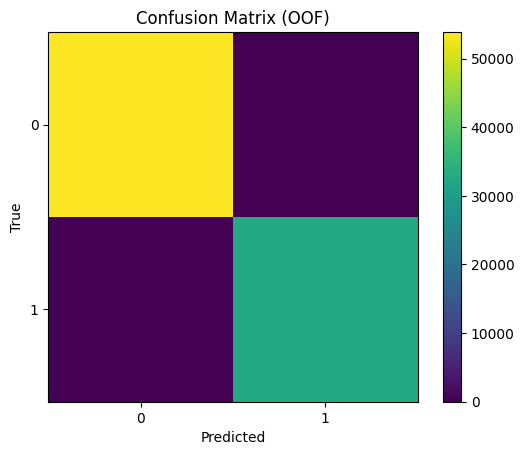

In [13]:

# Recompute OOF for diagnostics (using chosen model type)
pipe = make_pipeline(models[best_name])
oof = cross_val_predict(pipe, X, y, cv=cv, method='predict', n_jobs=-1, verbose=0)

print('Classification Report (OOF):')
print(classification_report(y, oof, digits=4))

cm = confusion_matrix(y, oof)
print('Confusion Matrix (OOF):\n', cm)

plt.figure()
plt.imshow(cm, interpolation='nearest')
plt.title('Confusion Matrix (OOF)')
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ['0','1'])
plt.yticks(tick_marks, ['0','1'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


## 6. Final Training & Inference on Test

In [14]:

# Ensure train/test have identical columns after preprocessing by using the pipeline
best_model = make_pipeline(models[best_name])
best_model.fit(X, y)

test_preds = best_model.predict(test)
# Ensure predictions are integers 0/1
test_preds = pd.Series(test_preds).astype(int).values

submission = pd.DataFrame({'attack': test_preds})
submission_path = Path('final_submission.csv')
submission.to_csv(submission_path, index=False)
print(f'Saved submission to: {submission_path.resolve()}')
display(submission.head())


Saved submission to: C:\Users\msair\Desktop\Neptune-Attack-Detection\final_submission.csv


,attack
0,1
1,0
2,1
3,1
4,1


## 7. (Optional) Save Fitted Pipeline

In [15]:

# You can persist the trained pipeline for reuse:
try:
    import joblib
    joblib.dump(best_model, 'best_pipeline.joblib')
    print('Saved: best_pipeline.joblib')
except Exception as e:
    print('Could not save model with joblib:', e)


Saved: best_pipeline.joblib



## 8. Notes & Tips

- If you observe extreme class imbalance, you can swap in imblearn's `SMOTE` or `RandomUnderSampler` in the pipeline.
- You can also try `class_weight='balanced'` for `HistGradientBoostingClassifier` by calibrating via `CalibratedClassifierCV` or use `XGBoost`/`LightGBM` if available.
- For leaderboard optimization, consider tuning the threshold using `predict_proba` and maximizing F1 on a validation split.
- If column names differ (e.g., `protocoltype` vs. `protocol_type`), this notebook automatically detects categorical columns by dtype, so no manual mapping is required.
- Submission file must include only one column named **`attack`**.
